# EDA

## Imports

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Quality Assessment

In [ ]:
df = pd.read_csv(os.path.join('..','data', 'raw','diabetic_data.csv'))
print(f'{df.shape[0]} rows and {df.shape[1]} columns')
df.head()

101766 rows and 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [47]:
len(df['patient_nbr'].unique()) #são 71518 pacientes, cerca 30000 saídas do hospital são de pacientes que foram readmitidos

71518

In [51]:
df.select_dtypes(include='number').info() #somente variaveis numericas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   admission_type_id         101766 non-null  int64
 3   discharge_disposition_id  101766 non-null  int64
 4   admission_source_id       101766 non-null  int64
 5   time_in_hospital          101766 non-null  int64
 6   num_lab_procedures        101766 non-null  int64
 7   num_procedures            101766 non-null  int64
 8   num_medications           101766 non-null  int64
 9   number_outpatient         101766 non-null  int64
 10  number_emergency          101766 non-null  int64
 11  number_inpatient          101766 non-null  int64
 12  number_diagnoses          101766 non-null  int64
dtypes: int64(13)
memory usage: 10.1 MB


In [52]:
df.select_dtypes(include='object').columns #variaveis categoricas

Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [53]:
null_counts = df.isnull().sum() # contagem de valores nulos por coluna, observamos que os valores nulos são muito altos, logo podemos retirar as colunas com muitos valores nulos
df_null_counts = null_counts[null_counts > 0]
df_null_counts

max_glu_serum    96420
A1Cresult        84748
dtype: int64

In [54]:
df = df.drop(columns=df_null_counts.index) #removendo colunas com muitos valores nulos para melhorar a qualidade da análise
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [55]:
df[df.duplicated()] #não há duplicações no dataset

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted


## Numeric Analyses

In [56]:
numerical_columns = df.select_dtypes(include='number').columns #descrição estatística das variáveis numéricas
numerical_columns = numerical_columns.drop(['patient_nbr','admission_type_id','encounter_id','admission_source_id','discharge_disposition_id','admission_source_id']) #removendo a coluna de id, pois não é relevante para a análise
numerical_df = df[numerical_columns]
numerical_df.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


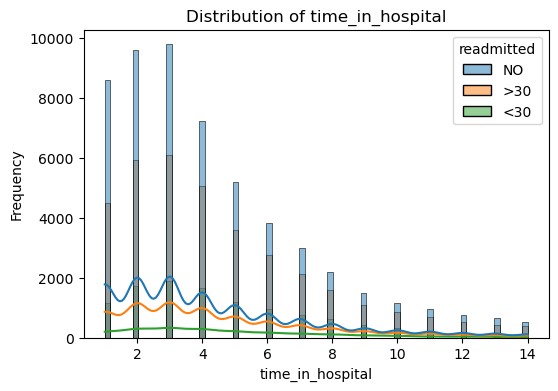

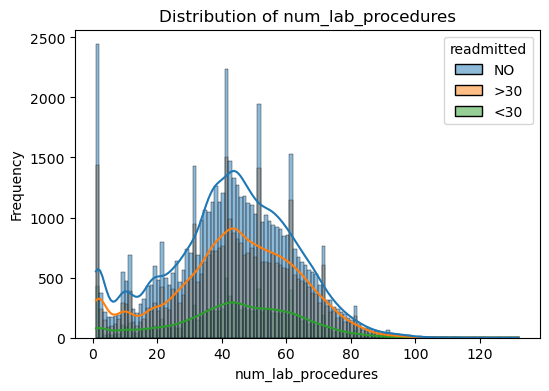

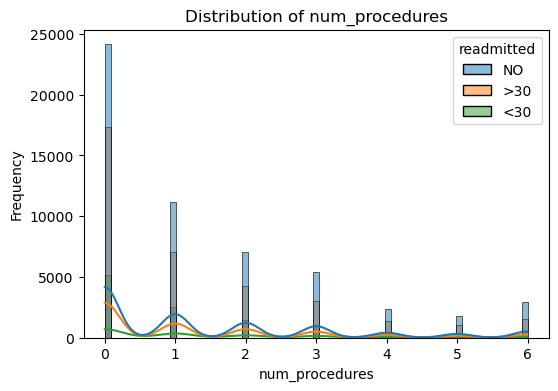

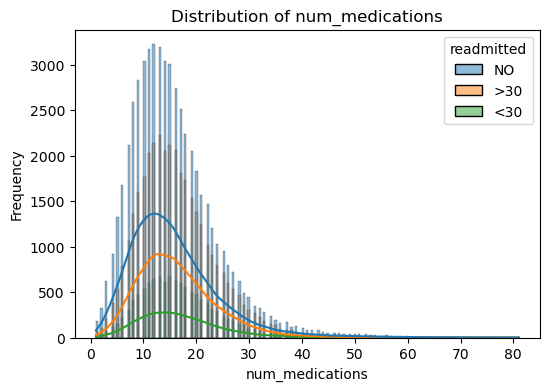

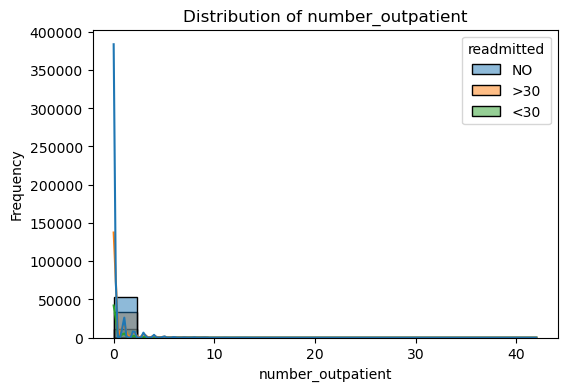

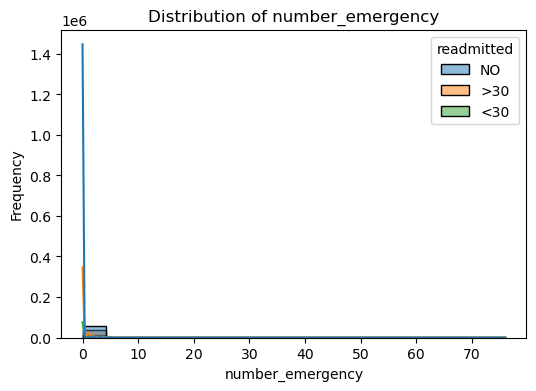

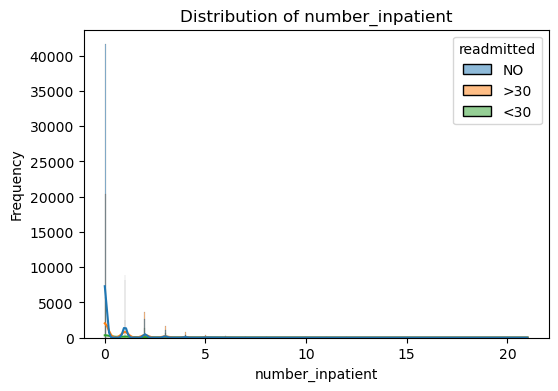

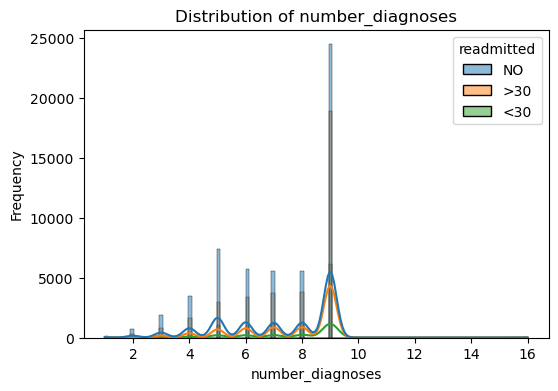

In [57]:

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, kde=True, hue='readmitted') 
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

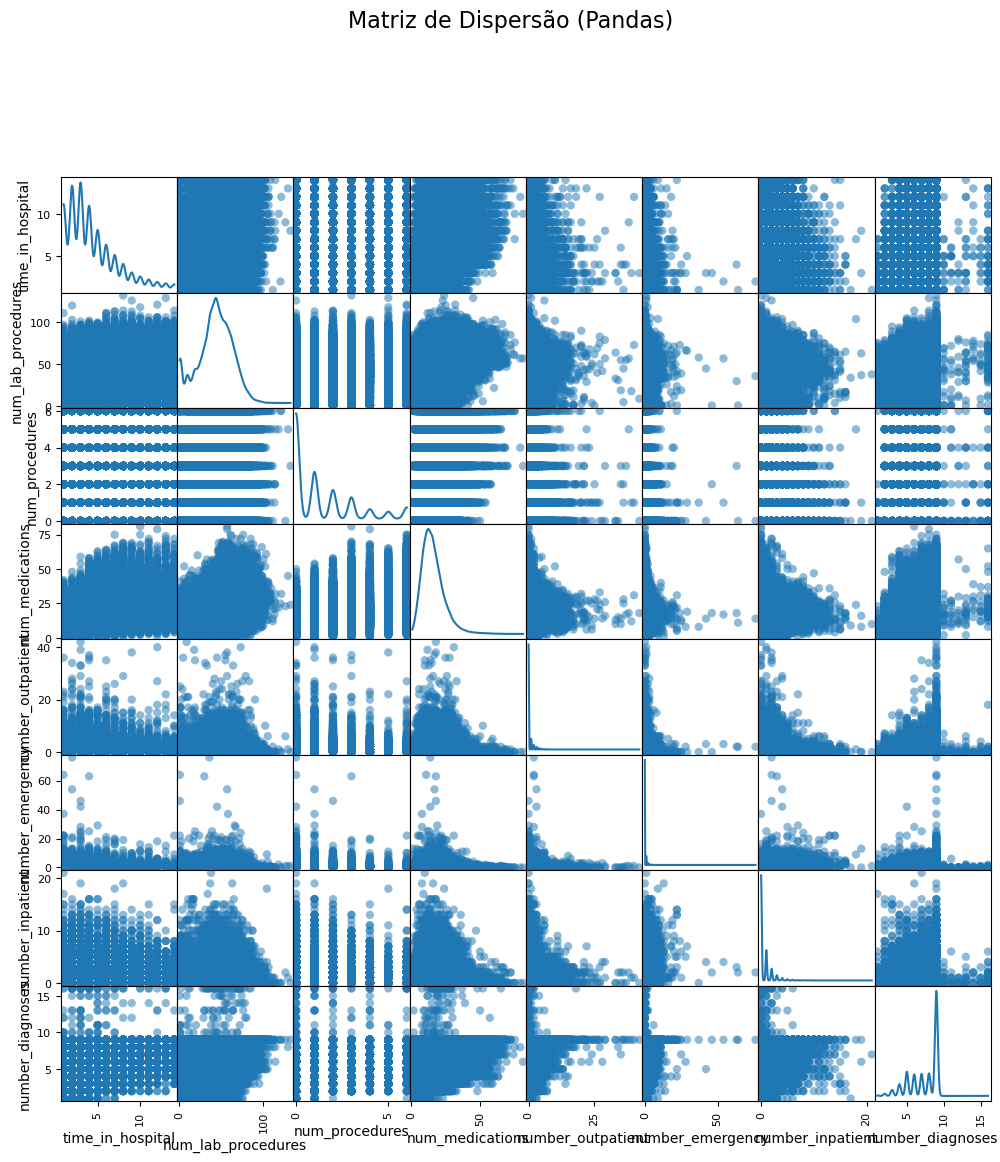

In [41]:
pd.plotting.scatter_matrix(df[numerical_columns], figsize=(12, 12), diagonal='kde', alpha=0.5, marker='o')
plt.suptitle('Matriz de Dispersão (Pandas)', y=1.02, fontsize=16)
plt.show()

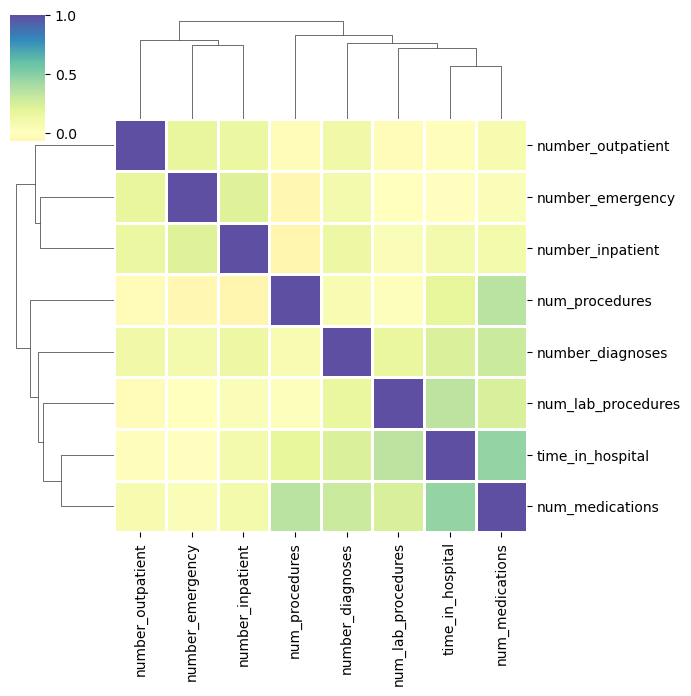

In [40]:
matrix_corr = numerical_df.corr(method='spearman') #matriz de correlação entre as variáveis numéricas utilizando o método de Spearman, que é mais adequado para não linearidades e dados com outliers
g = sns.clustermap( #mapa com uso de clusterização hierárquica para organizar as variáveis de acordo com suas correlações, facilitando a visualização de padrões
    matrix_corr,
    figsize=(7,7),     
    cmap='Spectral',           
    center=0,              
    annot=False,           
    fmt='.2f',            
    linewidths=.75,      
    cbar_kws={"shrink": .5} 
)

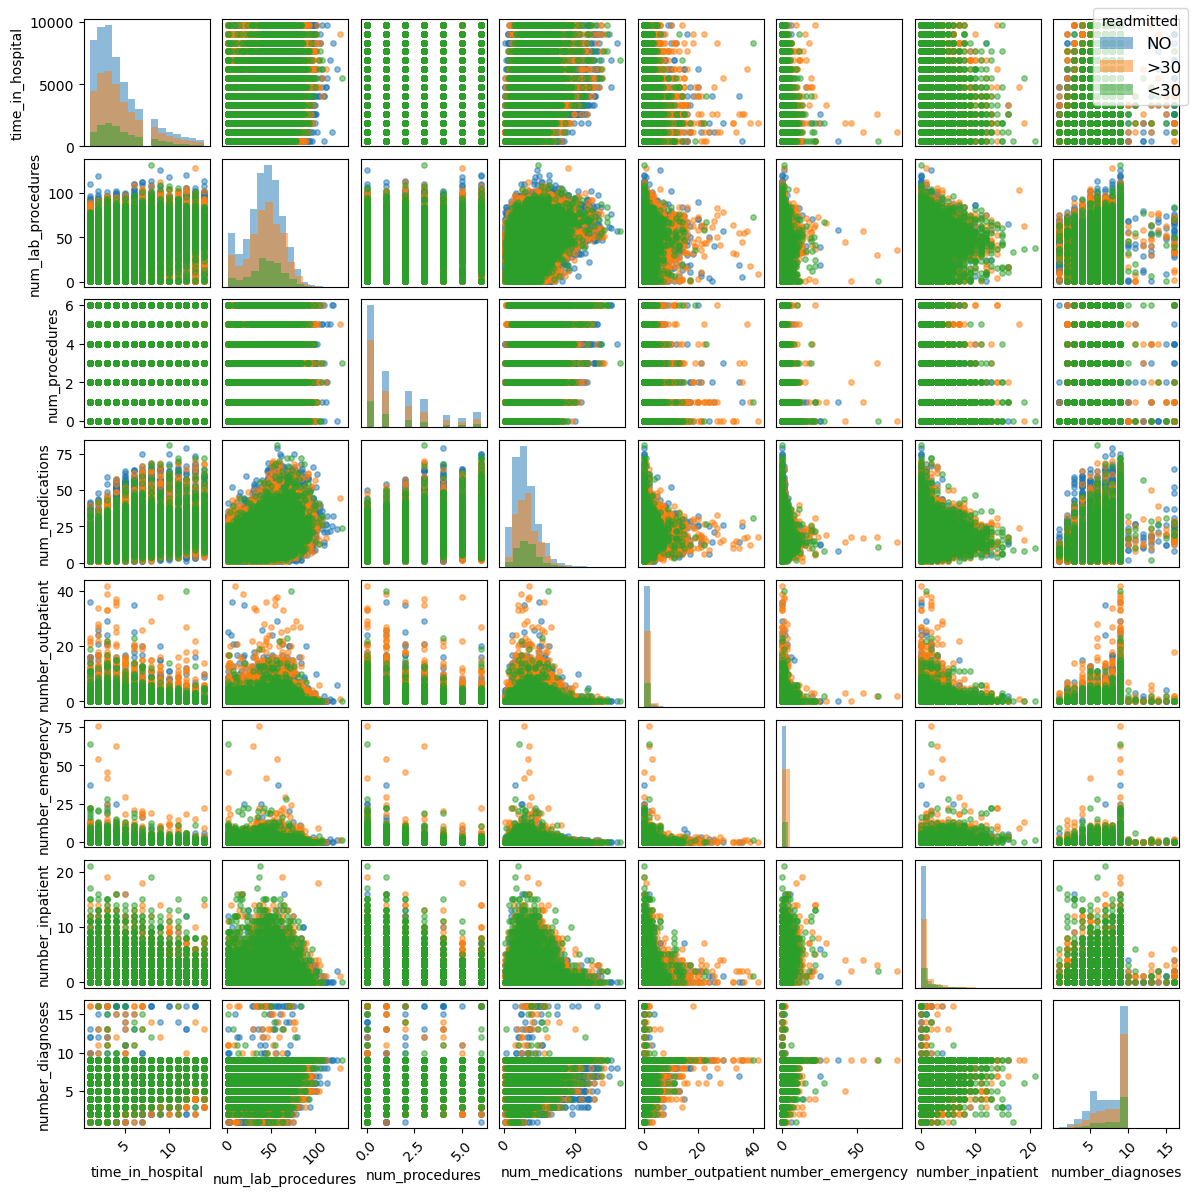

In [42]:
n = len(numerical_columns)
coluna_hue = 'readmitted'
categorias = df[coluna_hue].dropna().unique()

cores = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple'] 

fig, axes = plt.subplots(n, n, figsize=(12, 12))

for i, col_y in enumerate(numerical_columns):
    for j, col_x in enumerate(numerical_columns):
        ax = axes[i, j]
        
        for idx, cat in enumerate(categorias):
            subset = df[df[coluna_hue] == cat]
            
            cor_atual = cores[idx % len(cores)]
            
            if i == j:
                ax.hist(subset[col_x].dropna(), bins=15, color=cor_atual, alpha=0.5, label=cat)
            else:
                ax.scatter(subset[col_x], subset[col_y], color=cor_atual, alpha=0.5, s=15, label=cat)
        
        if i < n - 1:
            ax.set_xticks([]) 
        else:
            ax.set_xlabel(col_x, fontsize=10)
            ax.tick_params(axis='x', rotation=45)
            
        if j > 0:
            ax.set_yticks([]) 
        else:
            ax.set_ylabel(col_y, fontsize=10)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title=coluna_hue, fontsize=12)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1) 
plt.show()

## Categorical Analyses

In [ ]:
categorical_columns = df.select_dtypes(include='object').columns #descrição estatística das variáveis categóricas
categorical_df = df[categorical_columns]
categorical_df.describe()

In [ ]:
columns_question = categorical_df.apply(lambda col: (col == '?').sum()) #contagem de valores '?' em cada coluna categórica, indicando a quantidade de dados faltantes representados por '?'
columns_question #altos '?' indica falta de dados e ruídos, devem ser retiradas colunas com muitos '?' para melhorar a qualidade da análise

In [ ]:
categorical_df[categorical_df.columns[columns_question > 0]]

In [ ]:
categorical_df = categorical_df.drop(columns=['weight','medical_specialty','payer_code']) #removendo colunas com muitos '?' para melhorar a qualidade da análise, número de corte escolhido foi 2273
categorical_df

In [ ]:
categorical_columns = categorical_df.columns
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=categorical_df, x=col) #gráfico de barras para visualizar a distribuição das categorias em cada coluna categórica
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45) #rotaciona os rótulos do eixo x para melhor visualização
    plt.show()
    
#valores muito ruidosos, muitas categorias com poucos registros, dificultam a análise, retiramos eles, assim como aqueles que possuem um único registro

In [ ]:
cols_to_drop = ['diag_1', 'diag_2', 'diag_3', 'examide', 'citoglipton'] #colunas de altissima variação ou nenhuma variação
categorical_df = categorical_df.drop(columns=cols_to_drop)
categorical_df

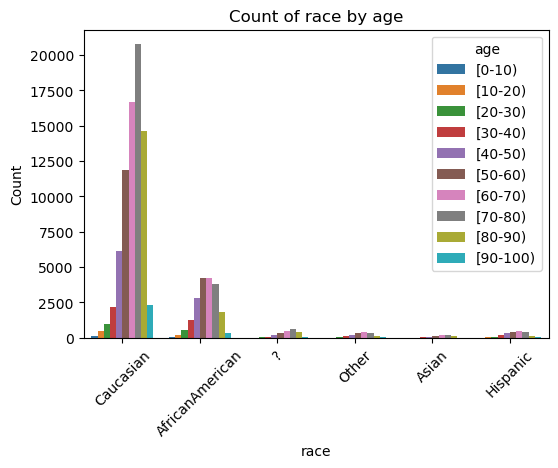

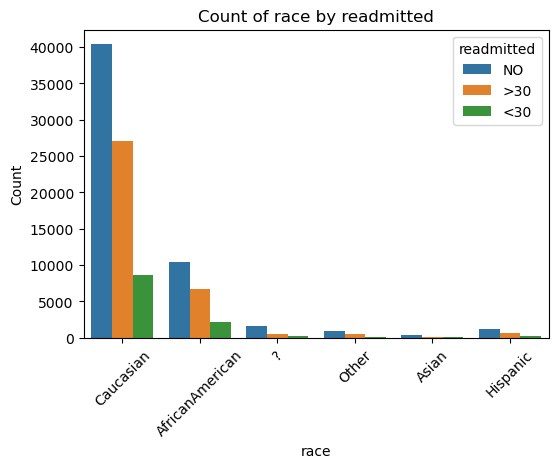

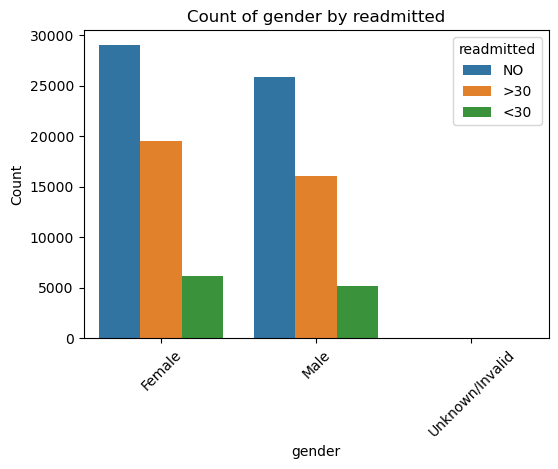

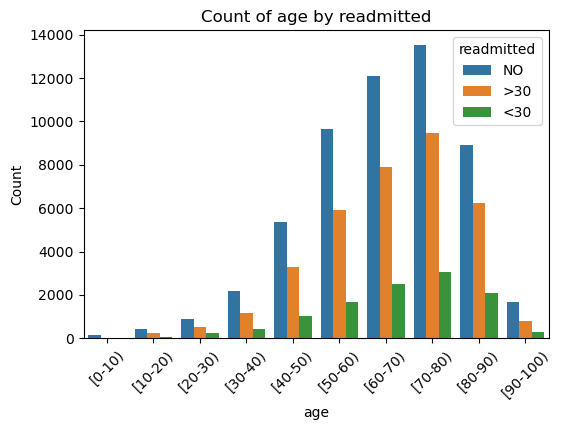

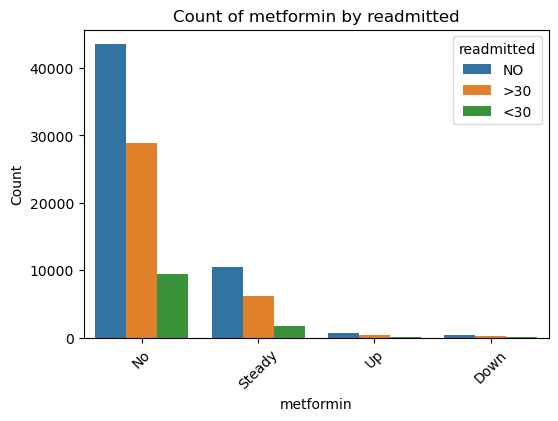

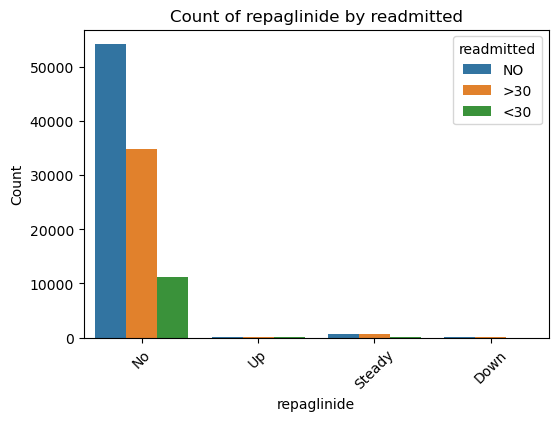

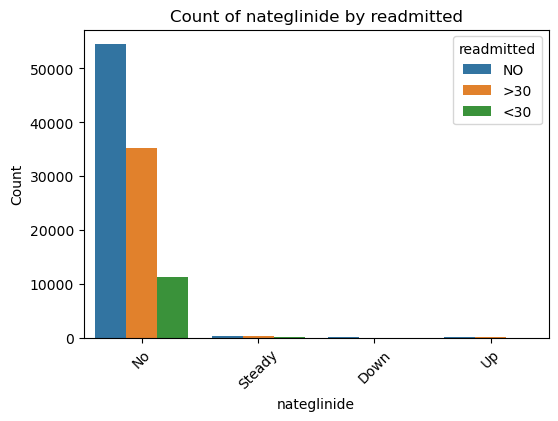

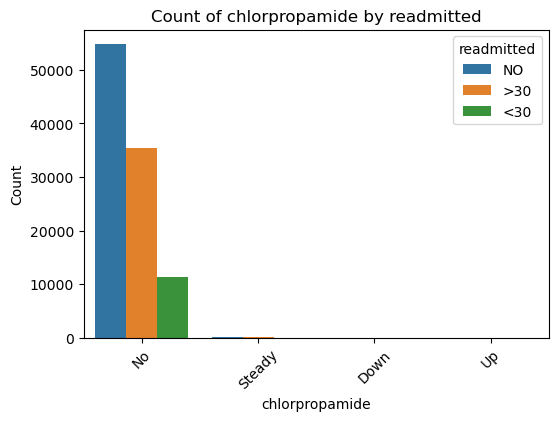

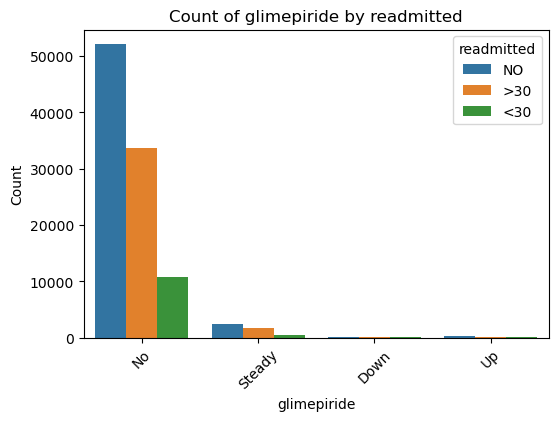

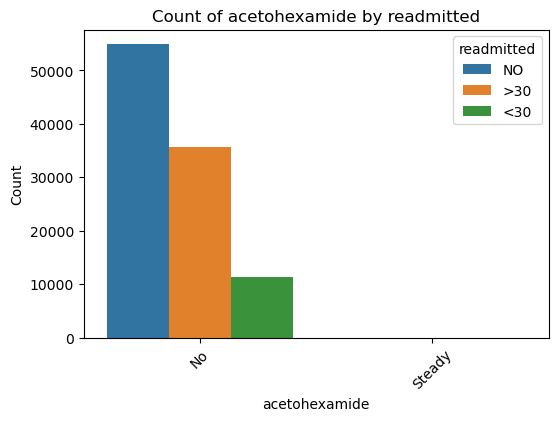

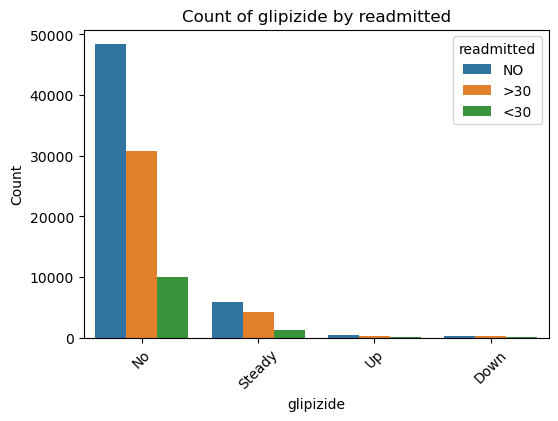

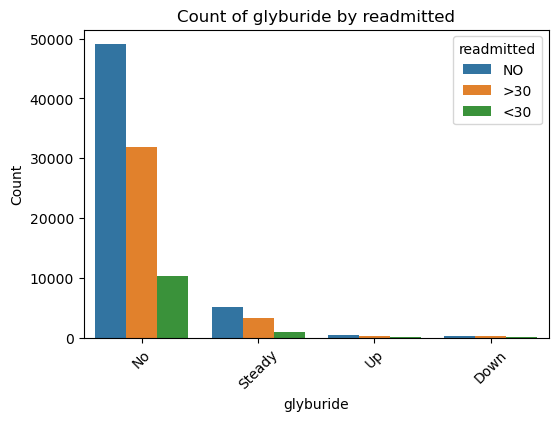

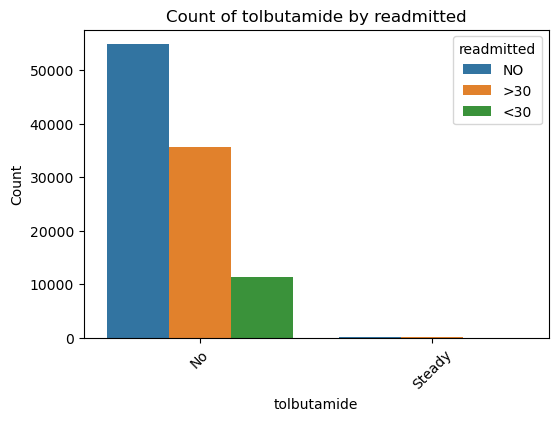

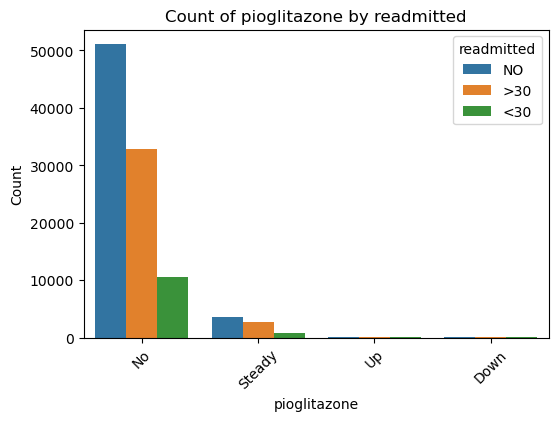

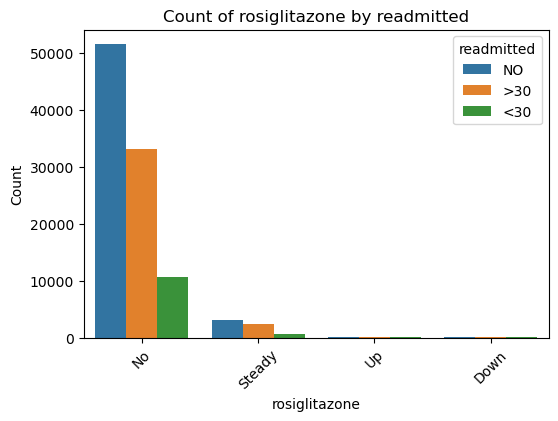

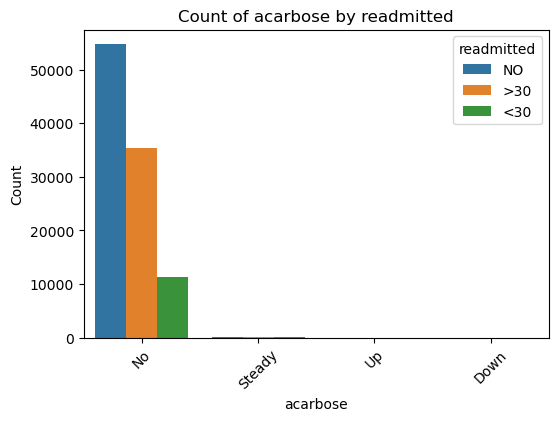

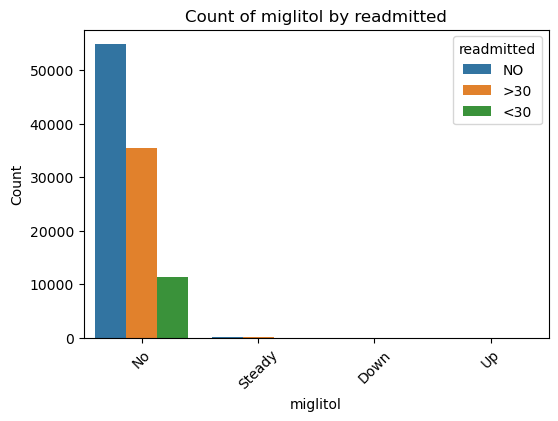

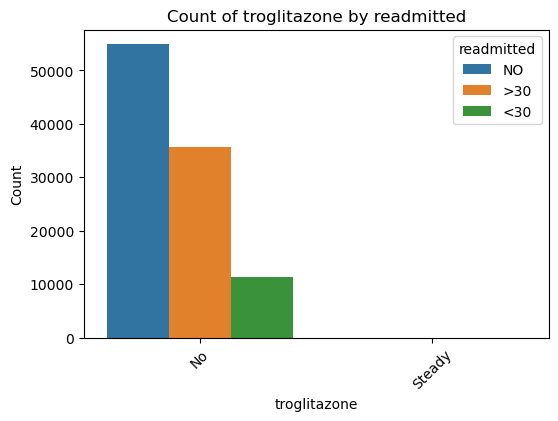

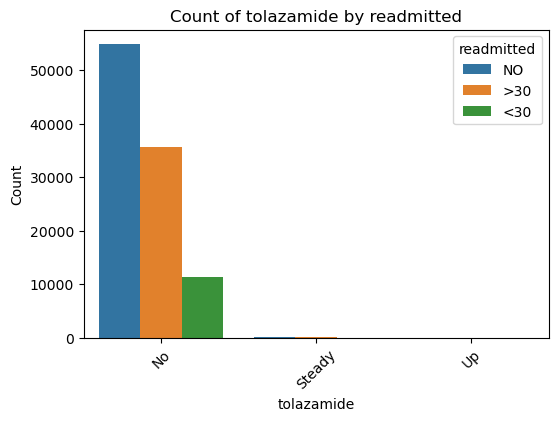

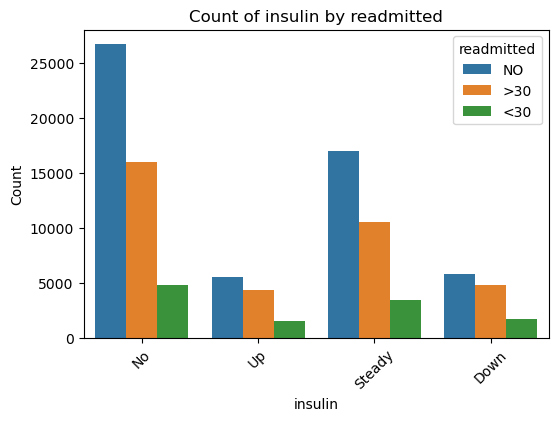

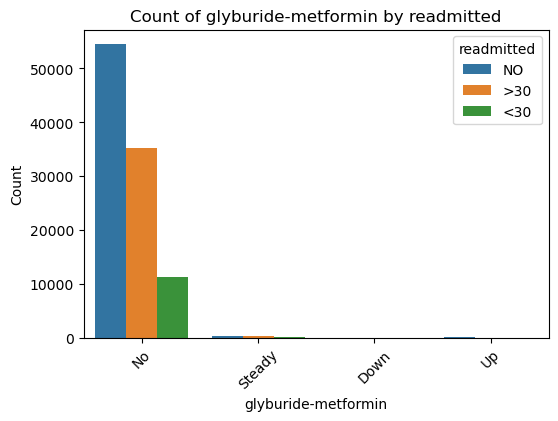

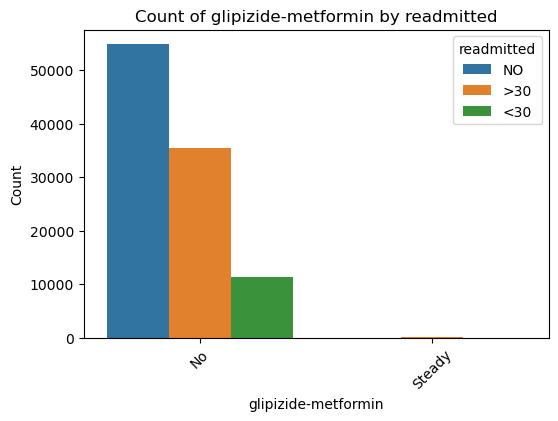

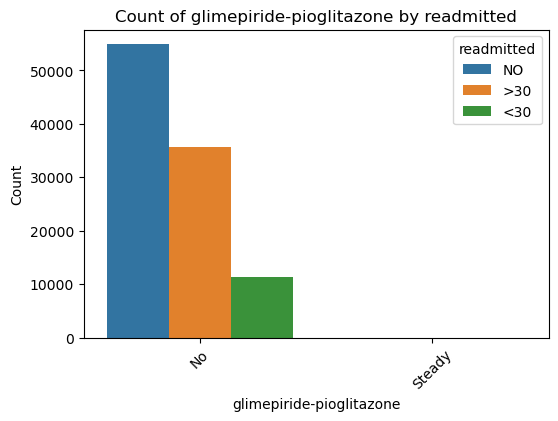

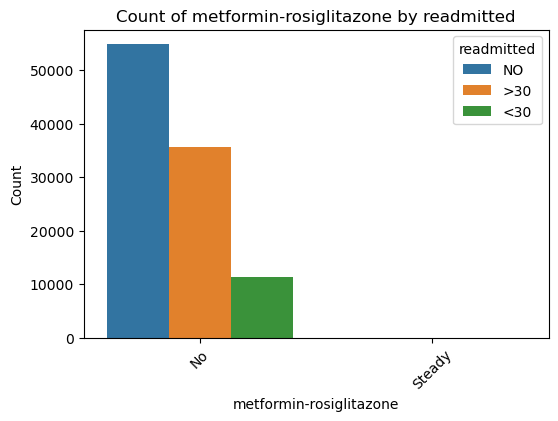

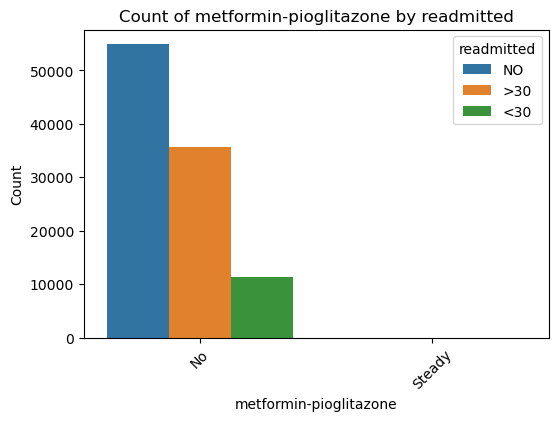

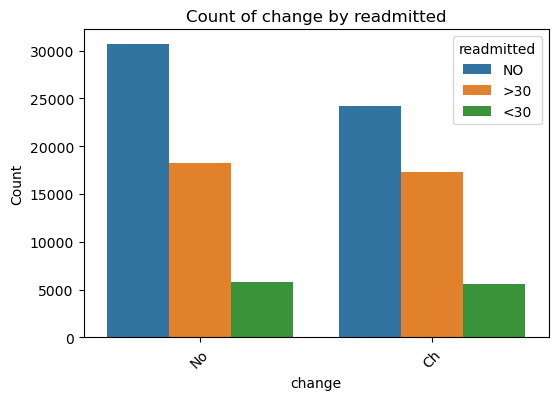

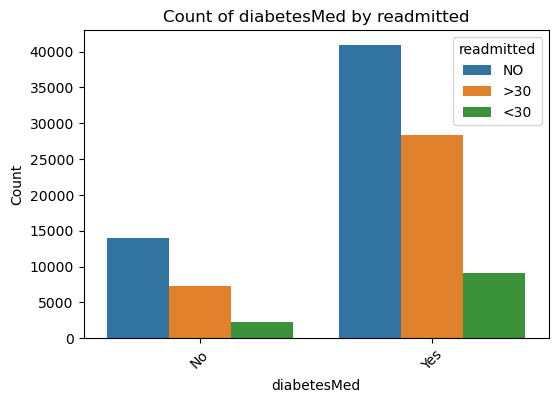

In [43]:
n=4

tuples = []

for col1 in categorical_df.columns:
    for col2 in categorical_df.columns:
        if col1 != col2 and ((col1, col2) not in tuples or (col2, col1) not in tuples) and ((len(categorical_df[col1].value_counts().index) > n and len(categorical_df[col2].value_counts().index) > n) or col1 == 'readmitted' or col2 == 'readmitted'): 
            tuples.append((col1, col2))
            tuples.append((col2, col1))
            try:
                plt.figure(figsize=(6,4))
                sns.countplot(data=categorical_df, x=col1, hue=col2) #gráfico de barras para visualizar a relação entre duas variáveis categóricas, usando a variável col2 para colorir as barras de acordo com suas categorias
                plt.title(f'Count of {col1} by {col2}')
                plt.xlabel(col1)
                plt.ylabel('Count')
                plt.xticks(rotation=45) #rotaciona os rótulos do eixo x para melhor visualização
                plt.legend(title=col2) #adiciona uma legenda para identificar as categorias da variável col2
                plt.show()
            except ValueError:
                print(f"Cannot plot {col1} vs {col2} due to too many categories.")
                continue
            

## Bivariate Analysis (Categorical and Numerical)

In [ ]:
df = numerical_df.join(categorical_df)
df

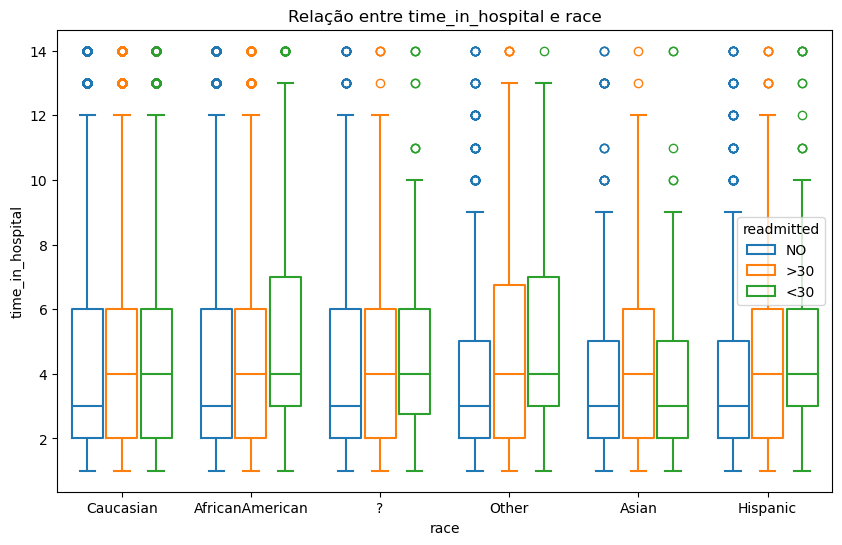

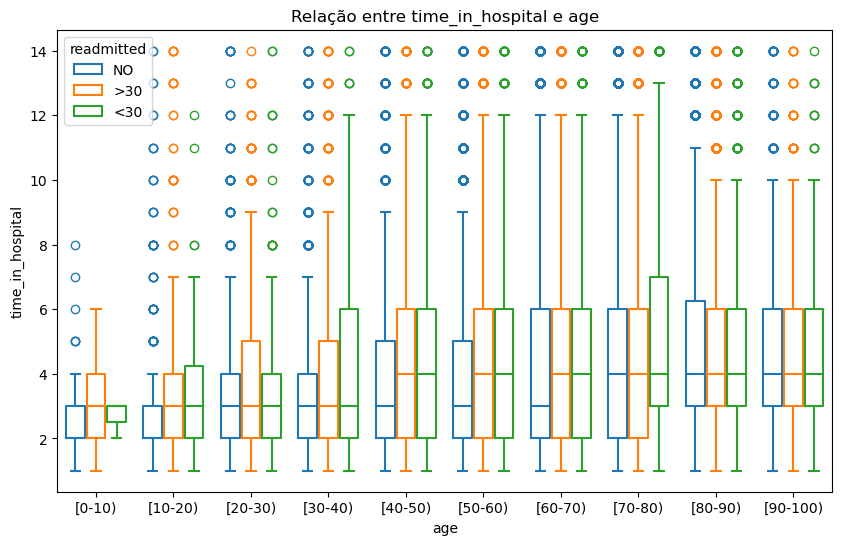

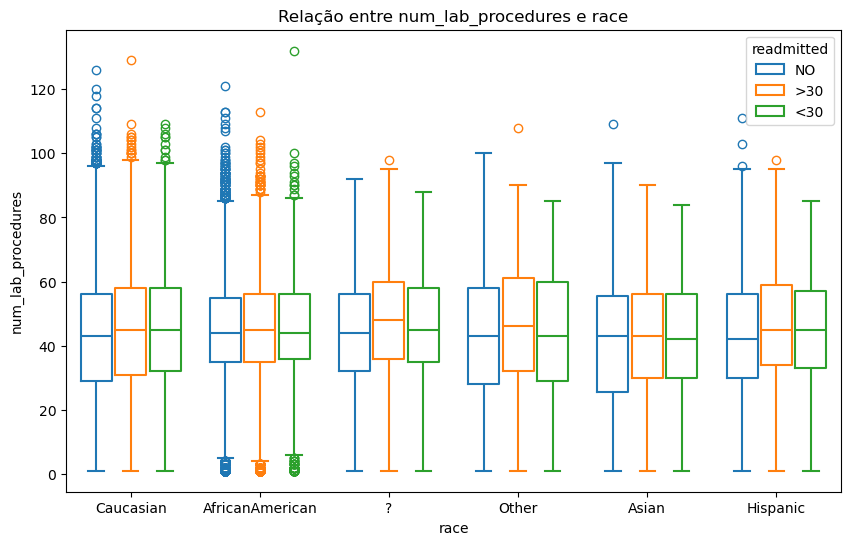

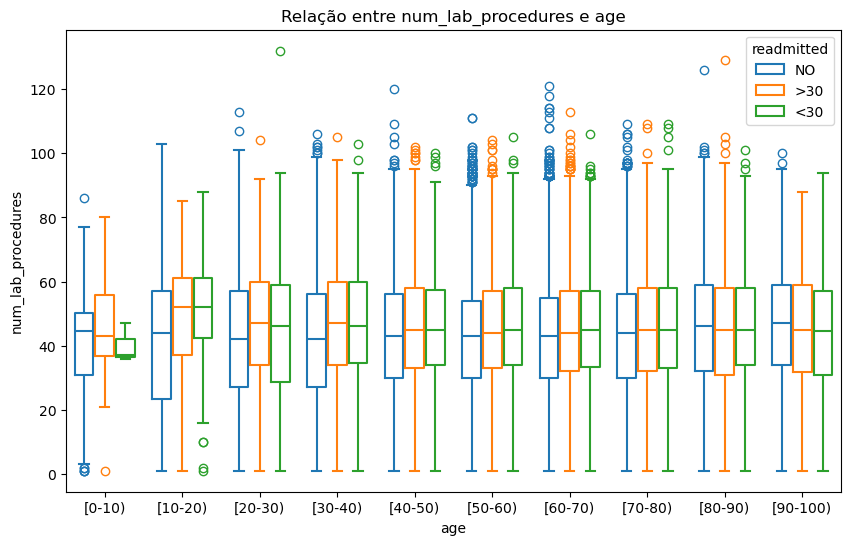

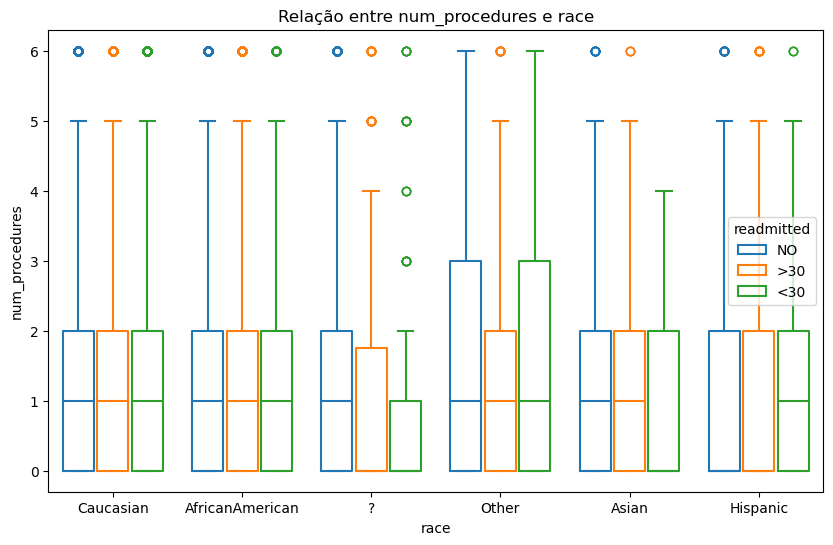

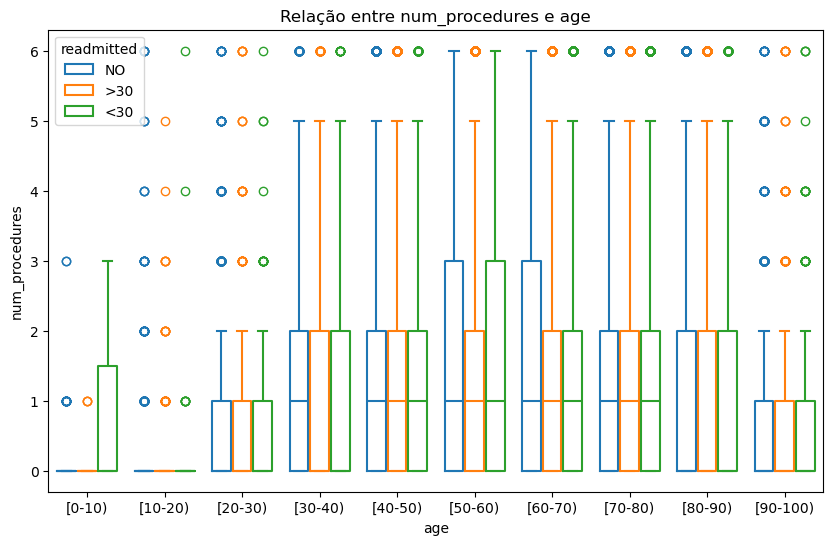

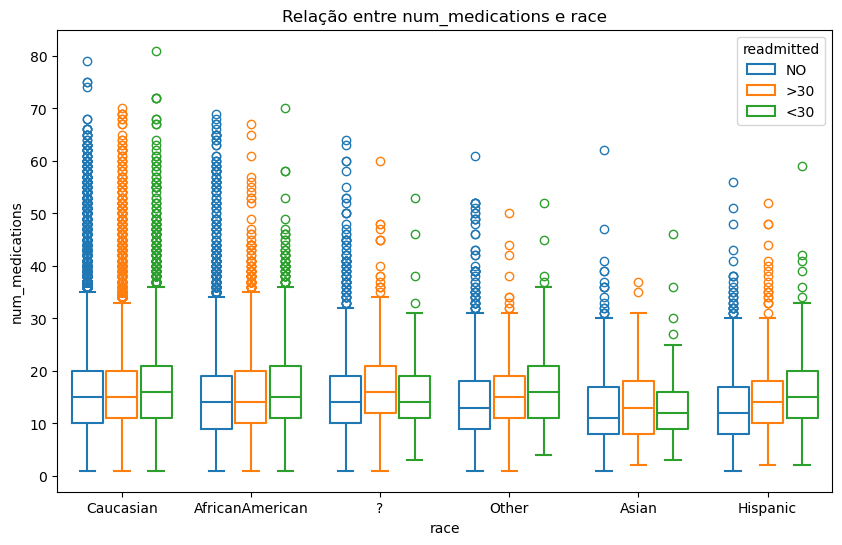

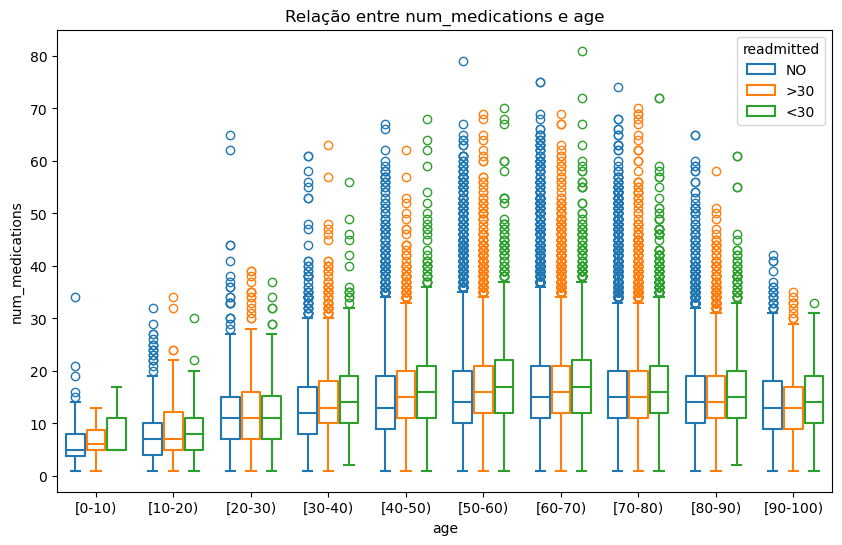

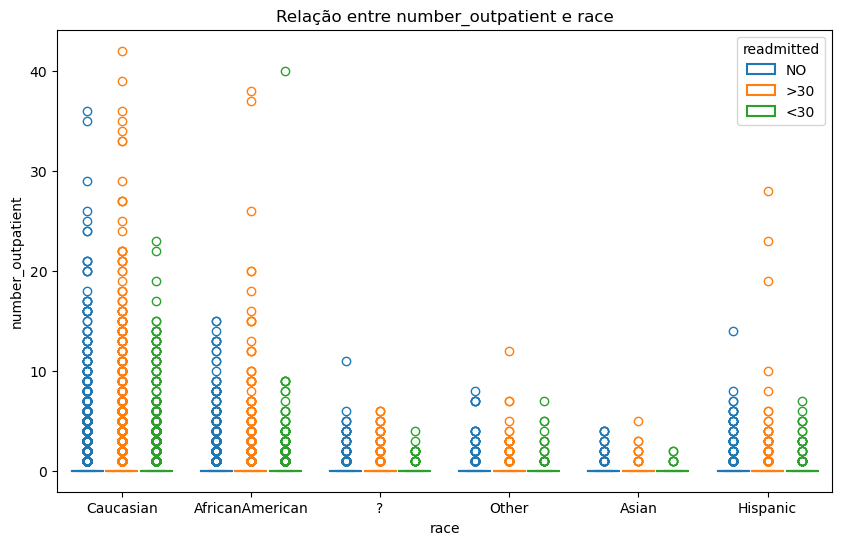

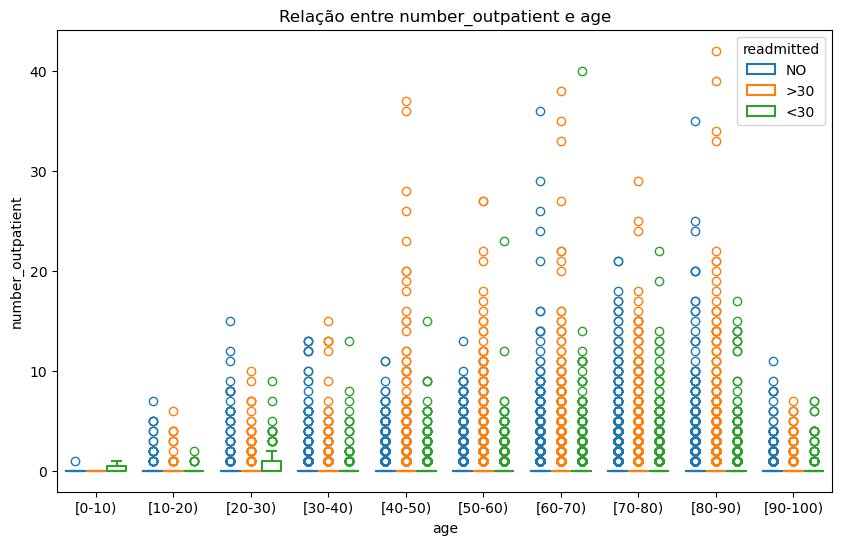

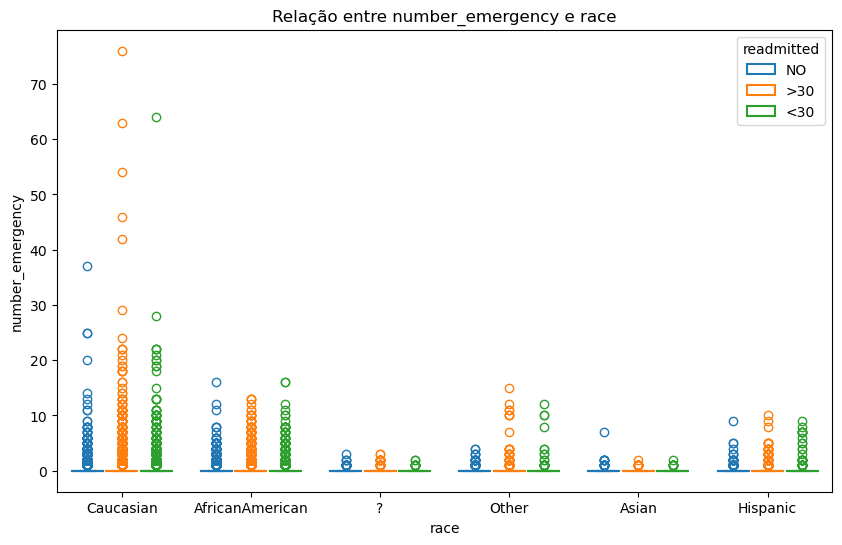

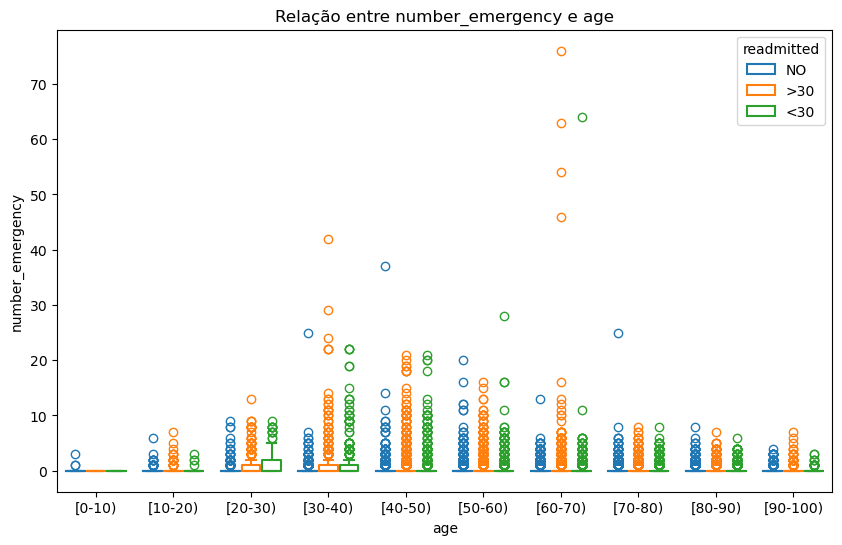

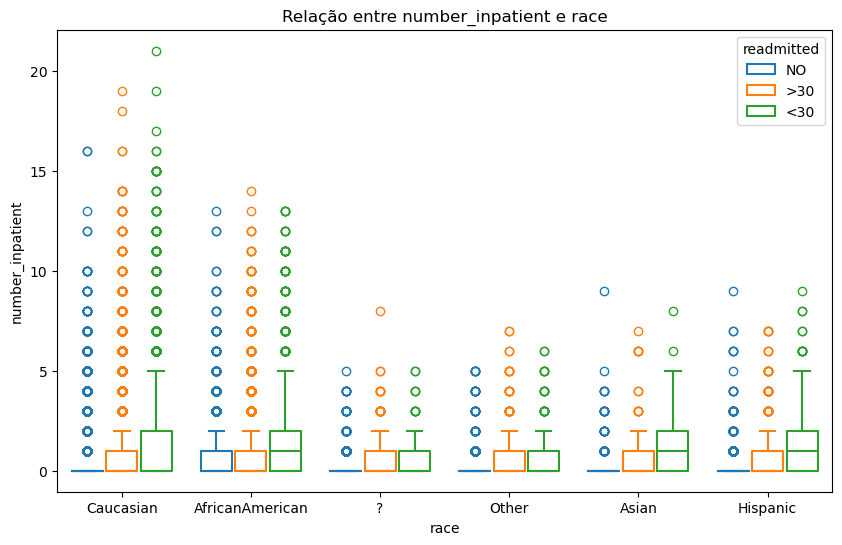

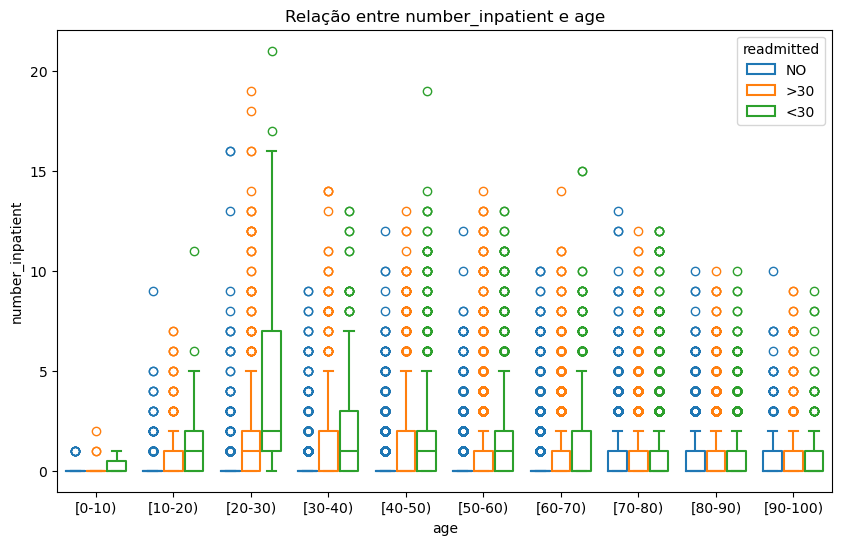

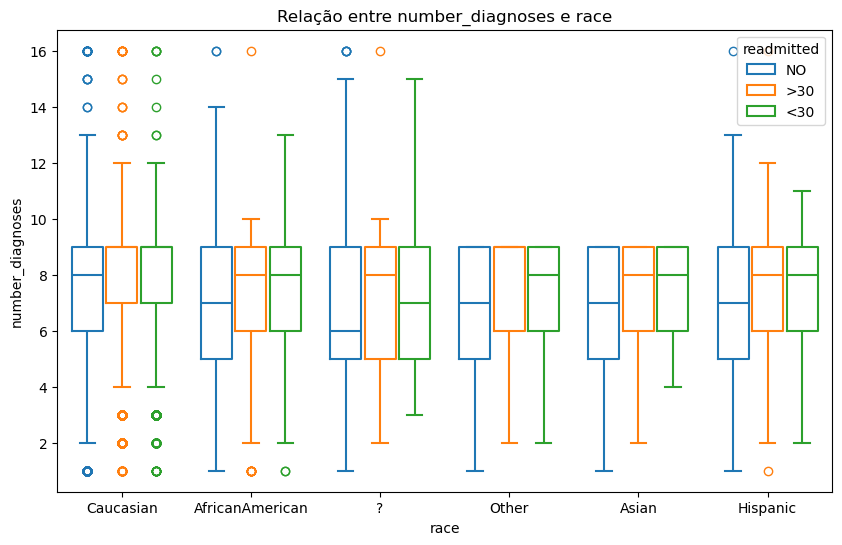

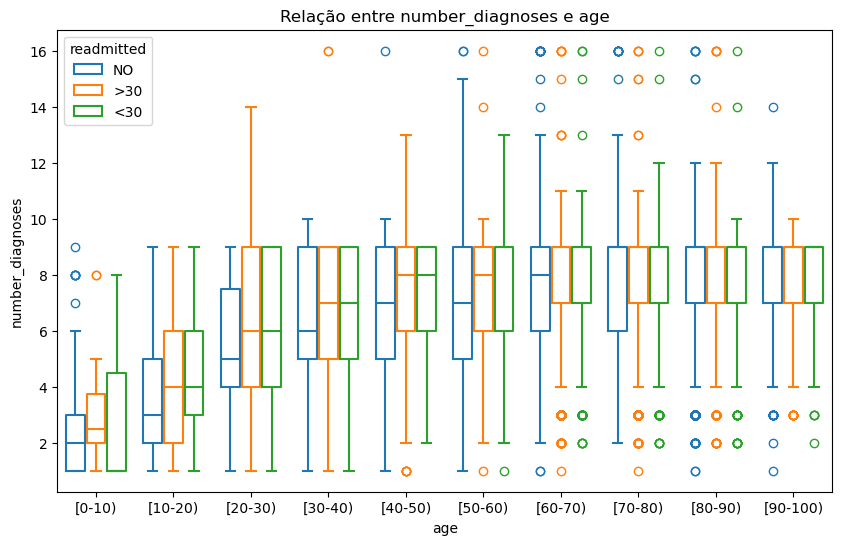

In [44]:
n = 4
tuples = []

for col1 in numerical_df.columns:
    for col2 in categorical_df.columns:
        if col1 != col2 and ((col1, col2) not in tuples or (col2, col1) not in tuples) and ((len(categorical_df[col2].value_counts().index) > n)):
            tuples.append((col1, col2))
            tuples.append((col2, col1))
            
            plt.figure(figsize=(10, 6)) 
            
            sns.boxplot(data=df, x=col2, y=col1, hue='readmitted', fill=False, gap=.1)
            
            plt.title(f'Relação entre {col1} e {col2}') 
            
            plt.show()